# Agent Supervisor

![](https://d.pr/i/gKezSO+)

In [1]:
%pip install -Uq langchain langchain-openai langchain-community langchain-tavily langchain-experimental langgraph

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://eu.api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")

## 도구 생성

In [3]:
from langchain_tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearch(max_results=3)
python_repl_tool = PythonREPLTool() # 보안위험 있음.


In [ ]:
# 헬퍼함수
# - 에이젼트 노드 실행기: 각 에이젼트의 답변을 사람메세지로 재가공.
from langchain_core.messages import HumanMessage

# 에이전트 실행 후, 마지막 응답을 HumanMessage로 감싸 반환하는 함수
def agent_node(state, agent, name):
    response = agent.invoke(state)
    # 에이전트의 응답 결과를 지정한 name의 HumanMessage로 변환
    return {'messages': [HumanMessage(content=response['messages'][-1].content, name=name)]}

## Supervisor Agent

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder  # 멀티메싲 프롬프트 구성 요소
from langchain.chat_models import init_chat_model
from enum import Enum
from pydantic import BaseModel  # 구조화 출력용
from typing import Literal      # 라우팅 결과 제한용

members = ['Researcher', 'Coder'] # 하위 에이젼트
system_prompt = """
다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업을 수행해야 합니다: {members}.

아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
모든 작업이 완료되면 FINISH로 응답하세요."
"""

options = members + ['FINISH']  # Supervisor가 선택할 수 있는 선택지

class RouteResponse(BaseModel): # Supervisor의 구조화 출력
    next: Literal["FINISH", "Researcher", "Coder"]  # 3가지 중 1개로 제한

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    MessagesPlaceholder(variable_name='messages'),  # 지금까지의 대화(messages)를 그대로 전달할 표시자
    ('system', '''
위 대화를 참고하여, 누가 다음으로 행동해야 하나요? 아니면 작업을 FINISH 해야 하나요?
다음중 하나를 선택하세요: {options}
''')
]).partial(options=options, members=', '.join(members)) # options/member를 partial로 미리 고정

llm = init_chat_model('gpt-4.1')

def supervisor_agent(state):
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    return supervisor_chain.invoke(state)   # state(messages 포함)를 입력받아 next 값 3개중 하나를 출력




c:\Users\Playdata\nlp\nlp_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Graph 조립

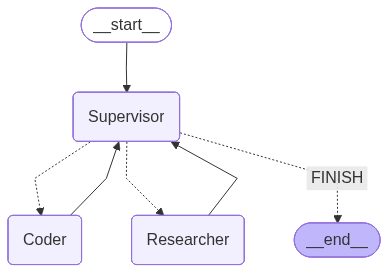

In [ ]:
from typing import TypedDict, Annotated, List       # 상태 타입 정의용
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages    # messages 누적 처리 유틸리티
from langchain_core.messages import BaseMessage     # messages 타입 힌트용
from langchain.agents import create_agent           # tool사용하는 에이전트 생성
import functools                                    # partial를 사용

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    next: str

# functools.partial(): 기존함수의 일부인자를 미리 채운 함수를 반환
research_agent = create_agent(llm, tools=[tavily_tool])
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

code_agent = create_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')


# 그래프 작성
workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", code_node)
workflow.add_node("Supervisor", supervisor_agent)

# 시작 -> Suvervisor
# Supervisor -> Researcher/Coder/END
# Researcher -> Supervisor
# Coder -> Supervisor
workflow.add_edge(START, 'Supervisor')
workflow.add_edge('Researcher', 'Supervisor')
workflow.add_edge('Coder', 'Supervisor')

# Supervisor의 next 값에 따른 분기 맵
conditional_map = {
    member: member for member in members    # 'Researcher' / 'Coder'는 동일한 이름의 노드로 라우팅
}
conditional_map['FINISH'] = END # FINISH면 종료로 라우팅
# STATE['next']를 기준으로 조건 분기 추가
workflow.add_conditional_edges('Supervisor', lambda state: state['next'], conditional_map)  
graph = workflow.compile()
graph

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='2026년 2월 1일을 포함한 최근 1달간 삼성전자 주가 주요 종가 데이터를 다음과 같이 정리할 수 있습니다.\n\n- 2026-02-05: 159,300원\n- 2026-02-04: 169,100원\n- 2026-02-03: 167,500원\n- 2026-02-02: 150,400원\n- 2026-01-30: 160,500원\n- 2026-01-29: 160,700원\n- 2026-01-28: 162,400원\n- 2026-01-27: 159,500원\n- 2026-01-26: 152,100원\n- 2026-01-23: 152,100원\n- 2026-01-22: 152,300원\n- 2026-01-21: 149,500원\n- 2026-01-20: 145,200원\n- 2026-01-19: 149,300원\n- 2026-01-16: 148,900원\n- 2026-01-15: 143,900원\n- 2026-01-14: 140,300원\n- 2026-01-13: 137,600원\n- 2026-01-12: 138,800원\n- 2026-01-09: 139,000원\n\n이 데이터를 기반으로 matplotlib 파이썬 코드를 제공해드릴게요.\n\n```python\nimport matplotlib.pyplot as plt\nimport matplotlib.font_manager as fm\n\n# 한글 폰트 설정 (예: 나눔고딕)\nplt.rcParams[\'font.family\'] = \'NanumGothic\'\n\ndates = [\n    "2026-01-09","2026-01-12","2026-01-13","2026-01-14","2026-01-15",\n    "2026-01-16","2026-01-19","2026-01-20","2026-01-21","2026-01-22",\n    "2026-

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

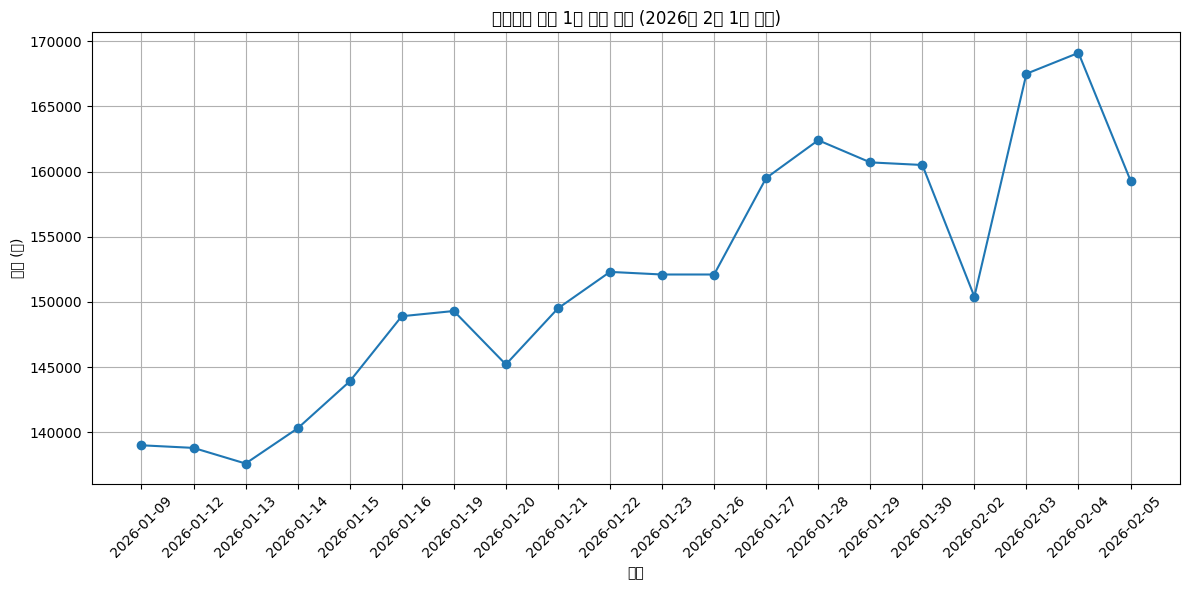

{'Coder': {'messages': [HumanMessage(content="아래는 2026년 2월 1일 기준 최근 1달간 삼성전자 주가 변화 추이를 한글이 깨지지 않게 시각화한 예시입니다. 한글 폰트는 'NanumGothic'으로 설정하였으며, 날짜와 종가 데이터를 기반으로 matplotlib 그래프를 그릴 수 있습니다.\n\n위 코드를 실제로 사용하시면, 삼성전자 주가 변화 추이를 한눈에 시각적으로 확인할 수 있습니다. 만약 'NanumGothic' 폰트가 없다면, 사용 가능한 한글 폰트로 변경해 주세요. \n\n혹시 실행 결과가 필요하시거나, 이미지를 보고 싶으시면 말씀해 주세요!", additional_kwargs={}, response_metadata={}, name='Coder', id='721d2eed-f502-48ba-a52a-bc69ff0113b0')]}}
{'Supervisor': {'next': 'FINISH'}}


In [14]:
# 코드 생성 요청
for chunk in graph.stream({
    'messages': [
        # ('human', '파이썬 Helloworld 출력하는 코드 작성하고, 콘솔에 출력해줘.')
        ('human', '오늘 2026년 2월 1일 기준 삼성전자 주식 최근 추이를 한글이 깨지지 않게 matplotlib 시각화해줘.')
    ]
}):
    print(chunk)

In [13]:
from IPython.display import Markdown

response = graph.invoke({
    'messages': [
        ('human', '오늘 2026년 2월 11일 기준 삼성전자 주식 최근 추이를 깨지지 않게 matplotlib 시각화해줘')
    ]
})
Markdown(response['messages'][-1].content)

2026년 2월 11일 기준 최근 삼성전자 주가의 변동 추이를 요약하면 다음과 같습니다.

- 2026년 초부터 1월 중순까지: 삼성전자 주가는 14만 원대에서 반등해 16만 원대를 돌파했습니다.
- 2026년 2월 초 최신(2026.2.5~2.10 기준): 삼성전자는 16만 5천 원~16만 원대 후반에 거래되고 있습니다. 2월 5일 종가 기준 159,300원, 2월 10일 기준 164,400원으로 최근 1개월 기준 큰 변동성과 함께 꾸준한 상승 흐름이 나타났습니다.
- 최근 52주 범위는 52,500~169,400원이고, 애널리스트 컨센서스는 중장기적으로 추가 상승 기대를 반영하고 있습니다.

아래 표는 최근 15거래일간의 삼성전자 종가(단위: 원)입니다.

| 날짜       | 종가    |
|------------|---------|
| 2026-02-10 | 164,400 |
| 2026-02-05 | 159,300 |
| 2026-02-04 | 169,100 |
| 2026-02-03 | 167,500 |
| 2026-02-02 | 150,400 |
| 2026-01-30 | 160,500 |
| 2026-01-29 | 160,700 |
| 2026-01-28 | 162,400 |
| 2026-01-27 | 159,500 |
| 2026-01-26 | 152,100 |
| 2026-01-23 | 152,100 |
| 2026-01-22 | 152,300 |
| 2026-01-21 | 149,500 |
| 2026-01-20 | 145,200 |
| 2026-01-19 | 149,300 |

이 데이터를 기반으로 matplotlib 그래프를 생성해드릴 수 있습니다. 곧 그래프 코드를 출력하겠습니다.
아래는 위의 최근 15거래일 삼성전자 주가 데이터를 기반으로 한 matplotlib 시각화 코드입니다.  
코드를 복사해 Python 환경(Colab, Jupyter, Python IDE 등)에 붙여넣으면 바로 차트를 확인할 수 있습니다.

```python
import matplotlib.pyplot as plt

dates = [
    "2026-01-19", "2026-01-20", "2026-01-21", "2026-01-22", "2026-01-23",
    "2026-01-26", "2026-01-27", "2026-01-28", "2026-01-29", "2026-01-30",
    "2026-02-02", "2026-02-03", "2026-02-04", "2026-02-05", "2026-02-10"
]
prices = [
    149300, 145200, 149500, 152300, 152100,
    152100, 159500, 162400, 160700, 160500,
    150400, 167500, 169100, 159300, 164400
]

plt.figure(figsize=(10,5))
plt.plot(dates, prices, marker='o', linewidth=2)
plt.xticks(rotation=45)
plt.title('삼성전자 최근 15거래일 종가 추이 (2026년 2월 11일 기준)')
plt.xlabel('날짜')
plt.ylabel('종가 (원)')
plt.grid(True)
plt.tight_layout()
plt.show()
```

만약 2024~2026년 장기 추이 시각화도 필요하다면 말씀해 주세요!

In [9]:
# 자료조사 요청
for chunk in graph.stream({
    'messages': [
        ('human', '저속노화에 대한 레포트 작성해줘')
    ]
}):
    print(chunk)

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content='물론입니다! 아래는 “저속노화(遲速老化, Slow Aging)”에 대한 레포트 예시입니다.\n\n---\n\n# 저속노화(Slow Aging)에 대한 레포트\n\n## 1. 서론\n\n현대 사회의 발전과 함께 인간의 기대 수명은 점차 늘어나고 있습니다. 이에 따라 ‘얼마나 오래 사느냐’ 뿐만 아니라 ‘얼마나 건강하게 사느냐’에 대한 관심이 높아지고 있습니다. 이러한 맥락에서 ‘저속노화(Slow Aging)’는 노화 현상을 최대한 늦추고, 삶의 질을 유지하며 살아가는 것을 목표로 하는 중요한 개념입니다.\n\n## 2. 저속노화의 개념\n\n저속노화란 노화의 속도를 늦추는 것을 의미합니다. 완전히 노화를 멈추는 것은 현재의 과학으로는 불가능하지만, 다양한 생활습관 개선과 의학적 개입을 통해 노화의 진행을 늦추거나, 노화로 인한 질병의 발생 시기를 늦출 수 있습니다. 즉, 시간에 따른 신체 기능 저하와 노화성 질병의 위험이 완만하게 진행되는 것을 추구합니다.\n\n## 3. 노화의 원인과 기전\n\n노화는 유전적 요인, 환경적 요인, 생활 습관 등에 의해 복합적으로 이루어집니다. 주요 기전은 다음과 같습니다.\n\n- **유전자 손상**: 세포 분열 과정에서 DNA가 손상되며, 복구 능력도 저하됩니다.\n- **활성산소(ROS) 축적**: 활성산소가 세포를 공격해 노화를 촉진합니다.\n- **염증 반응**: 만성 염증은 여러 노인성 질환의 원인이 됩니다.\n- **호르몬 변화**: 성장호르몬, 성호르몬 등의 감소는 신체 기능 저하에 영향을 줍니다.\n\n## 4. 저속노화를 위한 방법\n\n### (1) 식습관 개선\n- 항산화 식품(베리류, 녹황색 채소 등) 섭취\n- 저열량, 균형잡힌 식사\n- 가공식품, 포화지방, 당류 절제\n\n### (2) 규칙적인 운동\n- 유산소, 근력 운동 병행\n- 꾸준한